Total Faces Detected: 3


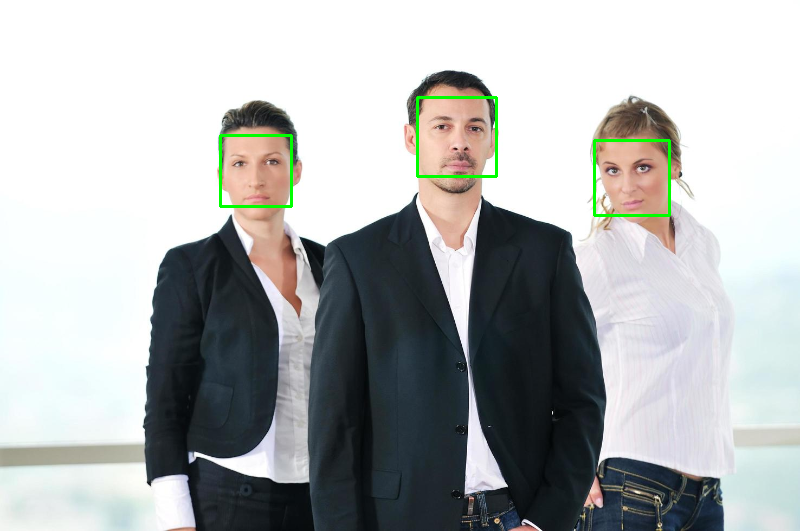

In [18]:
import cv2
import os
from google.colab.patches import cv2_imshow

def detect_faces_haar_balanced():
    # Make sure image exists
    if not os.path.exists("group.jpg"):
        print("Upload group.jpg first!")
        return

    # Load and resize image
    image = cv2.imread("group.jpg")
    image = cv2.resize(image, (800, int(image.shape[0] * 800 / image.shape[1])))

    # Convert to grayscale (Haar Cascade requires this)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # NEW TRICK: Equalize the histogram to boost contrast for shadowed faces in the back
    gray = cv2.equalizeHist(gray)

    # Load cascade
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )

    # The "Goldilocks" Parameters
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.05,  # 1.05 scans slower but much more thoroughly than 1.1
        minNeighbors=6,    # 6 is the sweet spot: drops the tie, keeps the faces
        minSize=(30, 30),  # Ignores tiny details
        flags=cv2.CASCADE_SCALE_IMAGE
    )

    print("Total Faces Detected:", len(faces))

    # Draw the green boxes
    for (x, y, w, h) in faces:
        cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)

    # Display the result
    cv2_imshow(image)

# Run the function
if __name__ == "__main__":
    detect_faces_haar_balanced()